In [8]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained("ostris/Flex.1-alpha", torch_dtype=torch.float16)
pipe = pipe.to("cuda")
pipe.safety_checker = None

prompt = "ronaldo, 8k, masterpiece, untradetailed"
h=800
w=640
steps=25
guidence=7.5
neg="woman,missing legs,missing "
image = pipe(prompt, height=h, weight=w, num_inference_steps=steps, guidance_scale=guidence, negative_prompt=neg).images[0]
image

model_index.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

text_encoder/config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

scheduler/scheduler_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

tokenizer/merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

(…)pytorch_model-00002-of-00002.safetensors:   0%|          | 0.00/6.42G [00:00<?, ?B/s]

(…)ion_pytorch_model.safetensors.index.json:   0%|          | 0.00/84.8k [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/168M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/4 [00:00<?, ?it/s]

ValueError: Pipeline <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> expected {'scheduler', 'vae', 'text_encoder', 'feature_extractor', 'unet', 'image_encoder', 'tokenizer', 'safety_checker'}, but only {'scheduler', 'vae', 'tokenizer', 'text_encoder'} were passed.

In [10]:
!pip install diffusers transformers accelerate
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

# Load the pipeline with all components specified
pipe = StableDiffusionPipeline.from_pretrained(
    "ostris/Flex.1-alpha",
    torch_dtype=torch.float16,
    # Explicitly load the missing components
    unet=UNet2DConditionModel.from_pretrained("ostris/Flex.1-alpha", subfolder="unet", torch_dtype=torch.float16),
    feature_extractor=CLIPFeatureExtractor.from_pretrained("openai/clip-vit-large-patch14"),
    image_encoder=None,  # If image_encoder is not needed, set it to None
    safety_checker=None, # Assuming safety_checker is disabled intentionally
)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to("cuda")

# ... (rest of your code)

NameError: name 'UNet2DConditionModel' is not defined

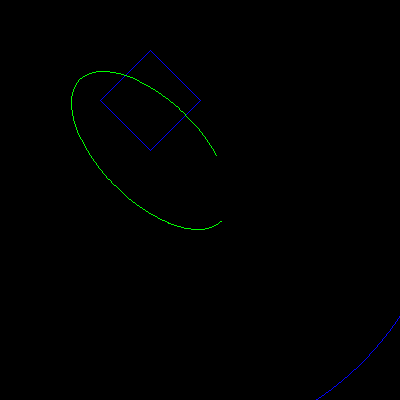

In [ ]:
import cv2
import numpy as np
import sys
from google.colab.patches import cv2_imshow

img = np.zeros((400,400,3),dtype = np.uint8)

pts1 = np.array([[100,100], [150,150], [200,100],[150,50], [100,100]], dtype=np.int32)
cv2.polylines(img, [pts1], False, (255,0,0))
cv2.circle(img,(150,150),300,(255,0,0))
cv2.ellipse(img, (150,150),(100,50), 45, 0,300,(0,255,0))
cv2.putText("Triplex")
cv2_imshow(img)

cv2.waitKey(0)

cv2.destroyAllWindows()

In [ ]:
import pandas as pd
score = pd.DataFrame({'русский':[100,80], "Математика":[75,80],"Английский":[90,95]},index=['aлтай','айдана'])
new_student = pd.Series({'русский':[100,80], "Математика":[75,80],"Английский":[90,95]},name='lsklsf')
score.append(new_student)
score

AttributeError: 'DataFrame' object has no attribute 'append'

In [ ]:
import pandas as pd
score = pd.DataFrame({'русский':[ 70, None, None,80,None,85], "Математика":[75,80,None,85,None,85],"имя":["алтай","айпери","жыргал","айнура","ижат","айдана"]},
                     index=['A','B','C','D','E','F'])
score.fillna(26,inplace=True)
score.fillna(score.mean(),inplace=True)
score.fillna(method='pad',inplace=True)
score


,русский,Математика,имя
A,70.0,75.0,алтай
B,70.0,80.0,айпери
C,70.0,80.0,жыргал
D,80.0,85.0,айнура
E,80.0,85.0,ижат
F,85.0,85.0,айдана


In [ ]:
import pandas as pd
score = pd.DataFrame({'русский':[ 70, None, None,80,None,85], "Математика":[75,80,None,85,None,85],"имя":["алтай","айпери","жыргал","айнура","ижат","айдана"]},
                     index=['A','B','C','D','E','F'])

score.fillna(method='bfill',inplace=True)
score

,русский,Математика,имя
A,70.0,75.0,алтай
B,80.0,80.0,айпери
C,80.0,85.0,жыргал
D,80.0,85.0,айнура
E,85.0,85.0,ижат
F,85.0,85.0,айдана


In [ ]:
v1 = 5**2
v2= 5**3
print(v1)
print(v2)

25
125


In [ ]:
l1 = 'Python всегда создает новый мир'
print(l1[5::-1])

nohtyP


In [ ]:
Given_data = [-20, -10, 0, 10, 20, 30, 40, 50, 60, 66, 70, 77, 80, 88, 90, 99, 100, 101, 102, 103]
cnA=0
cnArr_scores=0
cnC=0
cnD=0
cnF=0
for i in range(len(Given_data)):
    if Given_data[i]<70 and Given_data[i]>=55:

      cnC+=1
    elif Given_data[i]>=70 and Given_data[i]<=84:

      cnArr_scores+=1
    elif Given_data[i]>=85 and Given_data[i]<=100:

      cnA+=1
    elif Given_data[i]<55 and Given_data[i]>=40:

      cnD+=1
    elif Given_data[i]<40 and Given_data[i]>=0:
      cnF+=1

print("the amount of A is equal =",cnA, "rhe amount of Arr_scores is equal =",cnArr_scores, "the amount of C equal is =",cnC, "the amount of D is equal =",cnD,"the amount of F is equal =", cnF)

the amount of A is equal = 4 rhe amount of B is equal = 3 the amount of C equal is = 2 the amount of D is equal = 2 the amount of F is equal = 4


In [ ]:
Given_data = [-20, -10, 0, 10, 20, 30, 40, 50, 60, 66, 70, 77, 80, 88, 90, 99, 100, 101, 102, 103]
arr = []

def cal_score(s):
    if s >= 90 and s < 101:
        return 'A'
    elif s >= 80 and s <101:
        return 'Arr_scores'
    elif s >= 70 and s<101:
        return 'C'
    elif s >= 60 and s<101:
        return 'D'
    elif s >= 0 and s<101:
        return 'F'
    else:
        return None
i=0
while i < len(Given_data):

    result = cal_score(Given_data[i])
    i+=1
    arr.append(result)
    if result is not None:
        print(result)
print('F',arr.count('F'), 'D', arr.count('D'), 'C', arr.count('C'),"Arr_scores", arr.count('Arr_scores'),"A", arr.count('A'))


F
F
F
F
F
F
D
D
C
C
B
B
A
A
A
F 6 D 2 C 2 B 2 A 3


In [ ]:
print('%s:ifjl %d' % (name, score/7))
print('{}:flsdjflasj {}'.format(name, score))


Жаня:ifjl 11
Жаня:flsdjflasj 77


In [ ]:
names = ['James', 'Robert', 'Lisa', 'Mary', 'Алтай', 'Айдана', 'Нурбек', 'Жаня']
scores = [95, 86, 80, 77, 60, 90, 55, 77]
def cal_score(s):
  if s>=90 and s<101:
    return 'A'
  elif s>=80:
    return 'Arr_scores'
  elif s>=70:
    return 'C'
  elif s>=60:
    return 'D'
  elif s>0:
    return 'F'
  else:
    return ''

combined_data = zip(names, scores)

for name, score in combined_data:
    print(f'in todays exam he/she {name} got {cal_score(score)}')


in todays exam he/she James got A
in todays exam he/she Robert got B
in todays exam he/she Lisa got B
in todays exam he/she Mary got C
in todays exam he/she Алтай got D
in todays exam he/she Айдана got A
in todays exam he/she Нурбек got F
in todays exam he/she Жаня got C


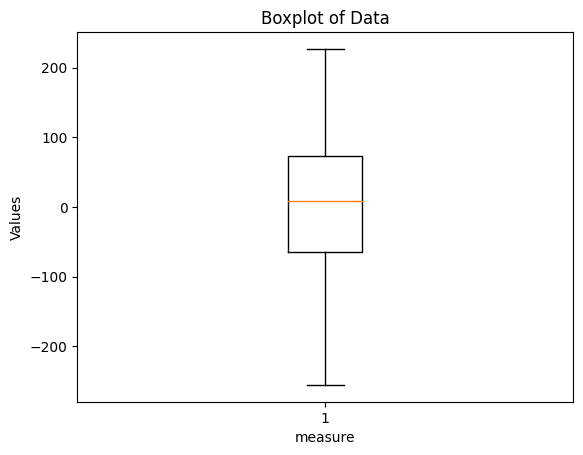

Summary Measures:
Mean: 5.980801553448499
Median: 9.409611943799815
Standard Deviation: 100.78822447165797
Variance: 10158.266192149315


array([ 176.4052346 ,   40.01572084,   97.87379841,  224.08931992,
        186.75579901,  -97.72778799,   95.00884175,  -15.13572083,
        -10.32188518,   41.05985019,   14.40435712,  145.4273507 ,
         76.10377251,   12.16750165,   44.38632327,   33.36743274,
        149.40790732,  -20.51582638,   31.30677017,  -85.40957393,
       -255.29898158,   65.36185954,   86.44361989,  -74.21650204,
        226.9754624 , -145.43656746,    4.57585173,  -18.718385  ,
        153.27792144,  146.93587699,   15.49474257,   37.81625196,
        -88.77857476, -198.07964682,  -34.79121493,   15.63489691,
        123.02906807,  120.23798488,  -38.73268174,  -30.23027506,
       -104.85529651, -142.00179372, -170.62701906,  195.07753952,
        -50.96521818,  -43.80743016, -125.279536  ,   77.74903558,
       -161.38978476,  -21.27402802,  -89.54665612,   38.69024979,
        -51.08051376, -118.06321841,   -2.81822283,   42.83318705,
          6.65172224,   30.24718977,  -63.43220937,  -36.27411

In [ ]:
import pandas as pd
import numpy as np
df = pd.DataFrame({'fruite':['apple', 'orange', 'grape'], 'price': [70, 80, 75], 'stocks':[100, 150,150]})

df1 = np.array([['apple', 'orange', 'grape'], [70, 80, 75], [100, 150,150]])
df2 = pd.DataFrame(df1, columns =['fruite', 'price', 'stocks'], index=['A','Arr_scores','C'] )

df2
from sklearn.datasets import *
iris = load_iris()
iris = pd.DataFrame(iris.data, columns = iris.feature_names)
iris.describe()
import matplotlib.pyplot as plt
import numpy as np

# Generate some random data
np.random.seed()
data = np.random.normal(loc=0, scale=100, size=100)

# Calculate summary measures
mean_value = np.mean(data)
median_value = np.median(data)
std_deviation = np.std(data)
variance = np.var(data)

# Create a boxplot
plt.boxplot(data)
plt.title('Arr_scoresoxplot of Data')
plt.ylabel('Values')
plt.xlabel('measure')
plt.show()

# Print summary measures
print("Summary Measures:")
print(f"Mean: {mean_value}")
print(f"Median: {median_value}")
print(f"Standard Deviation: {std_deviation}")
print(f"Variance: {variance}")
data



In [ ]:
import pandas as pd

score = {'курс':[1, 1, 1, 1, 2, 2],
         'класс':['А', 'А', 'В', 'В', 'С', 'С'],
         'пол':['женский','мужской','женский','мужской','женский','мужской'],
         'оценка': [76, 88, 85, 72, 68, 70]}

score = pd.DataFrame(score)
score



,курс,класс,пол,оценка
0,1,А,женский,76
1,1,А,мужской,88
2,1,В,женский,85
3,1,В,мужской,72
4,2,С,женский,68
5,2,С,мужской,70


In [ ]:
score = score.pivot_table(index=['курс', 'класс'], columns = 'пол', values = 'оценка')
score

пол         женский  мужской
курс класс                  
1    А           76       88
     В           85       72
2    С           68       70

In [ ]:
from math import ceil
def avg(d):
  return ceil((d["мужской"]+d["женский"]/2))
score.apply(avg,axis=1)

курс  класс
1     А        126
      В        115
2     С        104
dtype: int64

In [ ]:
import numpy as np
score.apply(np.sqrt, axis=0)

пол          женский   мужской
курс класс                    
1    А      8.717798  9.380832
     В      9.219544  8.485281
2    С      8.246211  8.366600

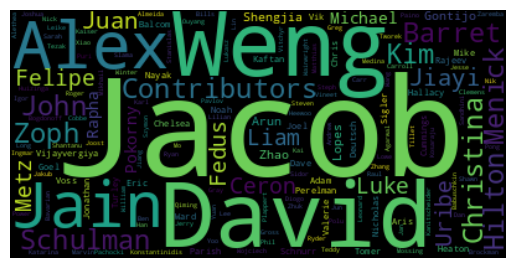

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
file_name = '/KNU-big data.txt'  # Читаем внешний файл

with open(file_name, encoding = 'UTF8') as f:
  text = f.read()

wordcloud_image = WordCloud().generate(text)

plt.imshow(wordcloud_image, interpolation = 'bilinear')
plt.axis("off")
plt.show()

In [ ]:
date = ['05-Feb', '06-Feb', '08-Feb', '09-Feb']
fruit_name = ['banana', 'grape', 'orange', 'peach']
close_price = [10500, 10300, 10100, 1100]
l=[]
for i in zip(date,zip(fruit_name,close_price)):

  l.append(i)
dict(l)


{'05-Feb': ('banana', 10500),
 '06-Feb': ('grape', 10300),
 '08-Feb': ('orange', 10100),
 '09-Feb': ('peach', 1100)}

In [ ]:
a = [1, 3, 5, 7, 9, 13, 15, 17, 19, 21, 22, 23, 25, 29, 41, 43, 45]
b = [4, 5, 6, 8, 13, 24, 35, 22, 14, 19]
c = [5, 8, 13, 19, 23, 45, 22]
d = [1, 3, 5, 7, 19, 13, 15, 30, 40, 20, 22]
e = [4, 5, 6, 8, 13, 22, 45, 19, 20, 50, 55]
f = [5, 8, 13, 19, 22, 24, 25, 48]
g=[]
def find(a,b,c,d,e,f):
  if a ==b==c==d==e==f:
    g.append(a)
for i in a:
  for j in b:
    for u in a:
      for t in b:
        for y in a:
          for x in b:
            find(i,j,u,t,y,x)

g


[5, 13, 19, 22]

In [ ]:
class Car:
    def __init__(self, wheel_size, color, engine_no, car_type):
        self.wheel_size = wheel_size
        self.color = color
        self.engine_no = engine_no
        self.car_type = car_type
    def move(self,speed):
      print(f'speed {speed} kilometer')
    def turn(self,s):
          print(s)
    def stop(self):
      print(self.wheel_size,self.color,self.engine_no,self.car_type)

my_car = Car(18, "blue","123456", "sedan")
my_car.move(50)
my_car.turn("right")
my_car.stop()

speed 50 kilometer
right
18 blue 123456 sedan


In [ ]:

class Car:
    instance_count = 0

    def __init__(self, size, color, engine, door, seat):
        self.size = size
        self.color = color
        self.engine = engine
        self.door = door
        self.seat = seat
        Car.instance_count +=1

car = Car(1,2,3,4,5)
print(car.instance_count)
car = Car(1,2,3,4,6)
print(car.instance_count)


1
2


In [ ]:
n = [2,7,4,6,1]
a =[]
i = 0
def cal(a,b):
  if a<b:
    return True
for i in range(len(n)):
    if n[i-1] <= n[i]:
      n[i-1], n[i]=n[i],n[i-1]

      print(n)





[1, 7, 4, 6, 2]
[7, 1, 4, 6, 2]
[7, 4, 1, 6, 2]
[7, 4, 6, 1, 2]
[7, 4, 6, 2, 1]


In [ ]:
import pandas as pd
df = pd.read_excel('/content/student score.xlsx')
df

,Student,Russian,English,Math,Average
0,Altai,80,90,85,85.000000
1,Ainura,90,95,95,93.333333
2,Apsamat,95,70,75,80.000000
3,Sapad,70,85,80,78.333333
4,Aidana,75,90,85,83.333333


In [ ]:
!pip install pydub
!pip install playsound
!pip install gTTS
!pip install librosa



In [ ]:
from gtts import gTTS
import os
mytext = '''
привет как дела '''
language = 'ru'
myobj = gTTS(text=mytext, lang = language,slow = False)
myobj.save("welcome.mp3")
os.system("mpg321 welcome.mp3")

32512

In [ ]:
from IPython.display import Audio
from IPython.core.display import display
def beep():
  display(Audio('/content/welcome.mp3', autoplay = True))
beep();

In [ ]:
!pip install pytube
from pytube import YouTube
url = 'https://www.youtube.com/watch?v=F216h08weQM'
yt = YouTube(url)
video_stream = yt.streams.get_highest_resolution()
video_stream.download(output_path='/content/')

VideoUnavailable: F216h08weQM is unavailable

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# Repeat the process
wine_load = load_wine()
wine = pd.DataFrame(wine_load.data, columns=wine_load.feature_names)
wine['Class'] = wine_load.target
wine['Class'] = wine['Class'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})
wine_type = wine['Class'].value_counts()

wine_type
wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,class_2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,class_2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,class_2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,class_2


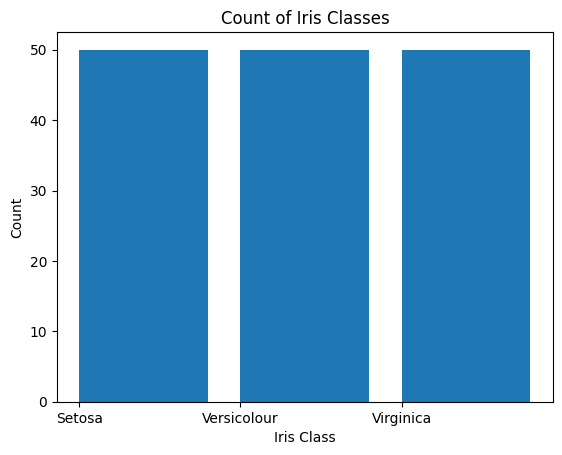

Class
Setosa         50
Versicolour    50
Virginica      50
Name: count, dtype: int64

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['Class'] = load_iris().target

# Map class numbers to class names
iris_df['Class'] = iris_df['Class'].map({0: 'Setosa', 1: 'Versicolour', 2: 'Virginica'})

# Count occurrences of each class
iris_type = iris_df['Class'].value_counts()

# Plotting the bar chart
plt.bar(iris_type.index, iris_type.values, width=0.8, align='edge')
plt.xlabel('Iris Class')
plt.ylabel('Count')
plt.title('Count of Iris Classes')
plt.show()

iris_type


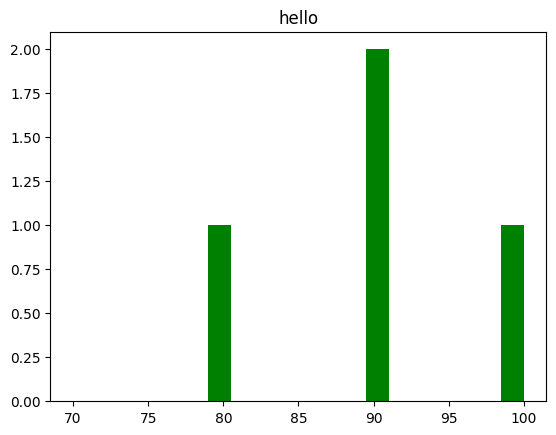

In [ ]:
import pandas as pd

# Define the student names and their scores
names = ['алтай', 'айдана', 'жыргал', 'айнура']
scores_data = {
    'Русский': [100, 95, 90, 85],
    'Математика': [100, 90, 80, 90],
    'Английский': [100, 99, 98, 97]
}

# Create the DataFrame
score = pd.DataFrame(scores_data, index=names)

score
#plt.hist('alcohol', bins = 8, range = (11, 15), color='purple', data = wine)​

#plt.show()
plt.title('hello')
plt.hist('Математика', bins = 20, range = (70,100), color = 'green', data = score)
plt.show()


#iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
#iris_df['Class'] = load_iris().target

# Map class numbers to class names
#iris_df['Class'] = iris_df['Class'].map({0: 'Setosa', 1: 'Versicolour', 2: 'Virginica'})

# Count occurrences of each class
#iris_type = iris_df['Class'].value_counts()





In [ ]:
l = [3, 6, 8, 10, 1, 2, 1]
k = ['F', 'a', 'G', 'b', 'c', 'G', 'A', 'z', 'C', 'S', 's', 'G']
def cal(l):
  n = len(l)
  for i in range(n-1):
    for j in range(n-i-1):
      if l[j]<l[j+1]:
        l[j],l[j+1]=l[j+1],l[j]
cal(l)
print(l)
def kal(l):
  n = len(l)
  for i in range(n-1):
    for j in range(n-i-1):
      if l[j]>l[j+1]:
        l[j],l[j+1]=l[j+1],l[j]
kal(k)
print(k)



[10, 8, 6, 3, 2, 1, 1]
['A', 'C', 'F', 'G', 'G', 'G', 'S', 'a', 'b', 'c', 's', 'z']


In [ ]:
a = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 1, 2, 5, 8]
b = ['a', 'b', 'c', 1, 2]
c = [5, 8, 13, 19, 23, 45, 22]
m = b+c
n = []
for i in a:
  for j in m:
    if i==j:
      n.append(i)


print(n)

['a', 'b', 'c', 1, 2, 5, 8]


In [ ]:
date = ['05-Feb', '06-Feb', '08-Feb', '09-Feb']
fruit_name = ['banana', 'grape', 'orange', 'peach']
close_price = [10500, 10300, 10100, 1100]
l=[]
for i in zip(date,zip(fruit_name,close_price)):

  l.append(i)
print(dict(l))
print(list(l))


{'05-Feb': ('banana', 10500), '06-Feb': ('grape', 10300), '08-Feb': ('orange', 10100), '09-Feb': ('peach', 1100)}
[('05-Feb', ('banana', 10500)), ('06-Feb', ('grape', 10300)), ('08-Feb', ('orange', 10100)), ('09-Feb', ('peach', 1100))]


In [ ]:
QUESTIONS = [
    ('Когда впервые', '2024'),
    ('Какая встроенная', 'input'),
    ('Какое ключевое ', 'for'),
    ('Какая твоя ', 'лагман'),
    ('Какое самое ', 'кну')
2]

for i,j in QUESTIONS:
  a = input(f'{i}?')
  if a == j:
    print('right')
  else :
    print('wrong')

Когда впервые?2024
right
Какая встроенная?2323
wrong
Какое ключевое ?2323
wrong
Какая твоя ?323
wrong
Какое самое ?кну
right


In [ ]:
!pip install sqlite3



ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)
ERROR: No matching distribution found for sqlite3


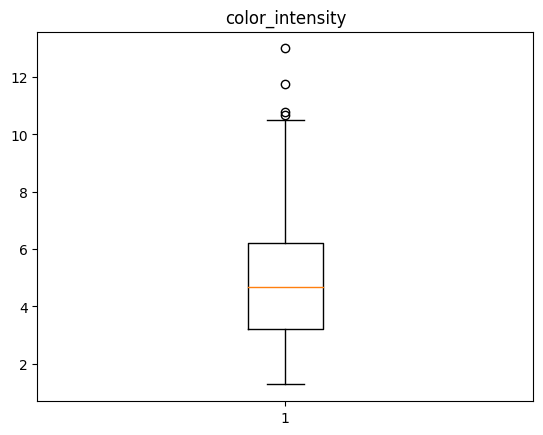

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

wine_load = load_wine()
wine = pd.DataFrame(wine_load.data, columns=wine_load.feature_names)
wine['Class'] = wine_load.target
wine['Class'] = wine['Class'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})

plt.boxplot(wine['color_intensity'], whis=1.5)
plt.title('color_intensity')
plt.show()


In [ ]:
wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,class_2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,class_2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,class_2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,class_2


In [ ]:
import numpy as np

def outliers_iqr(dt, col):
    quartile_1, quartile_3 = np.percentile(dt[col], [25, 75])
    iqr = quartile_3 - quartile_1
    lower_whis = quartile_1 - (iqr * 1.5)
    upper_whis = quartile_3 + (iqr * 1.5)
    outliers = dt[(dt[col] > upper_whis) | (dt[col] < lower_whis)]
    return outliers[[col]]

outliers = outliers_iqr(wine,'color_intensity')
outliers



,color_intensity
151,10.80
158,13.00
159,11.75
166,10.68


In [ ]:
import pandas as pd

product = pd.DataFrame({'Код продукта': ['G1', 'G2', 'G3', 'G4'],
                        'Название продукта': ['Молоко', 'Картошка', 'Хлеб', 'Курица']})

sale = pd.DataFrame({'Номер заказа': [1001, 1002, 1002, 1003, 1004],
                     'Код продукта': ['G4', 'G3', 'G1', 'G3', 'G5'],
                     'Количество заказа': [1, 4, 2, 2, 3]})

sale.merge(product,on = 'Код продукта', how = 'left')

,Номер заказа,Код продукта,Количество заказа,Название продукта
0,1001,G4,1,Курица
1,1002,G3,4,Хлеб
2,1002,G1,2,Молоко
3,1003,G3,2,Хлеб
4,1004,G5,3,NaN


In [ ]:

m=sale.merge(product,on = 'Код продукта', how = 'outer',sort = True)
m['Название продукта']=m['Название продукта'].fillna('cok')
m['Номер заказа'] = m['Номер заказа'].fillna(1002.4)
m['Количество заказа'] = m['Количество заказа'].fillna(2.4)
m

,Номер заказа,Код продукта,Количество заказа,Название продукта
0,1002.0,G1,2.0,Молоко
1,1002.4,G2,2.4,Картошка
2,1002.0,G3,4.0,Хлеб
3,1003.0,G3,2.0,Хлеб
4,1001.0,G4,1.0,Курица
5,1004.0,G5,3.0,cok


In [ ]:
import xml.etree.ElementTree as elemTree
from bs4 import BeautifulSoup

xmlStr = '''
<users>
    <user1 grade="gold">
        <name>Altai</name>
        <age>25</age>
        <birthday>19980215</birthday>
    </user1>
    <user2 grade="diamond">
        <name>Jirgal</name>
        <age>26</age>
        <birthday>19980417</birthday>
    </user2>
    <user3 grade="Ruby">
        <name>Ainura</name>
        <age>27</age>
        <birthday>19980617</birthday>
    </user3>
    <user4 grade="Topaz">
        <name>Aidana</name>
        <age>28</age>
        <birthday>19980817</birthday>
    </user4>
</users>
'''

tree = elemTree.fromstring(xmlStr)
soup=BeautifulSoup(xmlStr,"html.parser")

user1 = tree.find('./user1')
print(user1.tag)
print(user1.attrib)
print(user1.get('grade'))
n = user1.find('name')
print(n.text)
a = user1.find('age')
print(a.text)

user1
{'grade': 'gold'}
gold
Altai
25


In [ ]:
with open('data.xml','w')as f:
  f.write(xmlStr)

<function matplotlib.pyplot.show(close=None, block=None)>

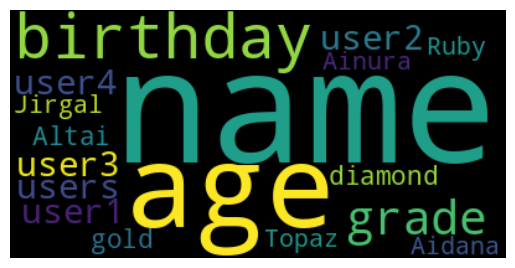

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nm = 'data.xml'
with open(nm , encoding = 'UTF8') as f:
  df = f.read()

wordcloud_image= WordCloud().generate(df)
plt.imshow(wordcloud_image,interpolation = 'bilinear')
plt.axis("off")
plt.show

        Русский  Математика  Английский
алтай       100         100         100
айдана       95          90          99
жыргал       90          80          98
айнура       85          90          97
['Русский', 'Математика', 'Английский']


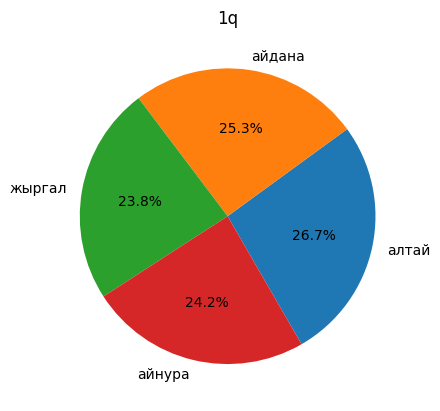

Русский
100    1
95     1
90     1
85     1
Name: count, dtype: int64


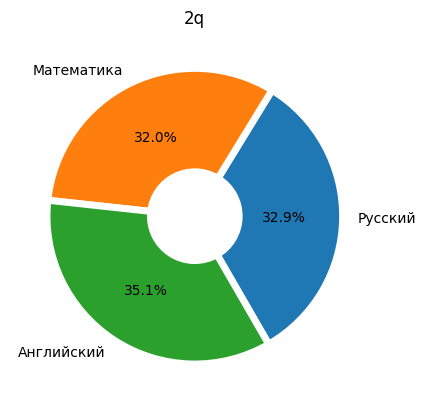

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

имя = ['алтай', 'айдана', 'жыргал', 'айнура']
score = pd.DataFrame({'Русский': [100, 95, 90, 85], 'Математика': [100, 90, 80, 90], 'Английский': [100, 99, 98, 97]}, index=имя)
m = list(score)
print(score)
print(m)
total_scores = score.sum(axis=1)


plt.pie(total_scores, labels=score.index, autopct='%1.1f%%', startangle=300)
plt.title('1q')
plt.show()


colors = ['#ff9999', '#ffc000', '#8fd9b6', '#d395d0']
wedgeprops={'width': 0.7, 'edgecolor': 'w', 'linewidth': 5}

plt.pie(score.sum(axis=0), labels=m, autopct='%1.1f%%', startangle=300,wedgeprops=wedgeprops)
plt.title('2q')
plt.show()

In [ ]:
import pandas as pd

score = {
    'курс': [1, 1, 1, 1, 2, 2],
    'класс': ['А', 'А', 'В', 'В', 'С', 'С'],
    'пол': ['женский', 'мужской', 'женский', 'мужской', 'женский', 'мужской'],
    'оценка': [76, 88, 85, 72, 68, 70]
}

score = pd.DataFrame(score)

score = score.pivot_table(index=["курс","класс"],columns="пол",values='оценка')
score


пол         женский  мужской
курс класс                  
1    А           76       88
     В           85       72
2    С           68       70

In [ ]:
score = score.reset_index().melt(id_vars=['курс','класс'],var_name='пол',value_name='оценка')
score


,курс,класс,пол,оценка
0,1,А,женский,76
1,1,В,женский,85
2,2,С,женский,68
3,1,А,мужской,88
4,1,В,мужской,72
5,2,С,мужской,70


In [ ]:
import numpy as np
score = pd.DataFrame(score)
score.apply(np.max,axis=0)

пол
женский    85
мужской    88
dtype: int64

In [ ]:
from math import ceil
score = score.pivot_table(index=["курс","класс"],columns="пол",values='оценка')
def avg(df):
  return ceil((df['мужской']+df['женский'])/2)
score.apply(avg,axis=1)

курс  класс
1     А        82
      В        79
2     С        69
dtype: int64

In [ ]:
import json

json_string = """
{
  "name" : "Алтай",
  "age" : 25,
  "city" : "Бишкек",
  "pets" : [
    {"name":"Пушистый", "type":"кот"},
    {"name":"Приятель", "type":"собака"},
    {"name":"Приятель", "type":"собака"},
    {"name":"Приятель", "type":"собака"}
  ],
  "friends": [
   {"name":"Боб", "age":30},
   {"name":"Чарли", "age":28},
   {"name":"Дэйв", "age":27},
   {"name":"Дэйв", "age":27},
   {"name":"Дэйв", "age":27}
  ],
  "contact":{
    "phone": "123-456-789",
    "e-mail": "alice@gmail.com"
 }
}
"""

data=json.loads(json_string)
print(data["name"])
print(data["pets"][1]["name"])
print(data["friends"][1]["age"])
print(data["contact"]["phone"])


Алтай
Приятель
28
123-456-789


In [ ]:
print(data["friends"][3]["name"])
print(data["friends"][0]["age"])
print(data["contact"]["phone"])

Дэйв
30
123-456-789


In [ ]:
print(data["friends"][0]["name"])

Боб


In [ ]:
with open('data.json','w')as f:
  f.write(json_string)

In [ ]:
with open('data.json', 'r') as f:
    data = json.load(f)
data


{'name': 'Алтай',
 'age': 25,
 'city': 'Бишкек',
 'pets': [{'name': 'Пушистый', 'type': 'кот'},
  {'name': 'Приятель', 'type': 'собака'},
  {'name': 'Приятель', 'type': 'собака'},
  {'name': 'Приятель', 'type': 'собака'}],
 'friends': [{'name': 'Боб', 'age': 30},
  {'name': 'Чарли', 'age': 28},
  {'name': 'Дэйв', 'age': 27},
  {'name': 'Дэйв', 'age': 27},
  {'name': 'Дэйв', 'age': 27}],
 'contact': {'phone': '123-456-789', 'e-mail': 'alice@gmail.com'}}